In [1]:
from collections import defaultdict
from __future__ import annotations
from typing import List, Dict, Tuple
import random
import numpy as np
from sympy import *

# Simplicial Complexes & Persistent Laplacian Computation

This section creates the Simplex and SimplicialComplex classes as well as a function to compute the persistent Laplacians. This was created by Shiv. We suspect that existing code (see PETLS: PErsistent Topological Laplacian Software) includes a faster version of this.

In [2]:
class Simplex:
    def __init__(self, vertices: list[int]):
        self.n = len(vertices) - 1
        self.vertices = tuple(sorted(vertices))

    def get_immediate_children(self) -> list[Simplex]:
        if self.n == 0:
            return []
        return [
            Simplex([*self.vertices[:i], *self.vertices[i + 1 :]])
            for i in range(self.n + 1)
        ]

    def __str__(self) -> str:
        return f"Simplex({' '.join(str(v) for v in self.vertices)})"

    def __repr__(self) -> str:
        return self.__str__()

    def __eq__(self, other: Simplex) -> bool:
        return self.vertices == other.vertices

    def __hash__(self) -> int:
        return hash(self.vertices)

In [3]:
class SimplicialComplex:
    def __init__(self, simplices: list[Simplex]):
        # It will be useful later to keep the simplices graded by dimension.
        self.graded_simplices = defaultdict(list)
        for simplex in simplices:
            self.graded_simplices[simplex.n].append(simplex)
        self.largest_n = max(self.graded_simplices.keys())
        self.fill_in_gaps()
        self.remove_duplicates()
        self.sort_simplices()

    def fill_in_simplex(self, simplex: Simplex):
        if simplex in self.graded_simplices[simplex.n]:
            return
        self.graded_simplices[simplex.n].append(simplex)
        for child in simplex.get_immediate_children():
            self.fill_in_simplex(child)

    def fill_in_gaps(self):
        for n in range(1, self.largest_n + 1):
            for simplex in self.graded_simplices[n]:
                for child in simplex.get_immediate_children():
                    self.fill_in_simplex(child)

    def remove_duplicates(self):
        for n in range(self.largest_n + 1):
            self.graded_simplices[n] = list(set(self.graded_simplices[n]))

    def sort_simplices(self):
        for n in range(self.largest_n + 1):
            self.graded_simplices[n] = sorted(
                self.graded_simplices[n], key=lambda simplex: simplex.vertices
            )

    def __str__(self) -> str:
        return f"SimplicialComplex({dict(self.graded_simplices)})"

    def __repr__(self) -> str:
        return self.__str__()

    def get_boundary_matrix_map(self) -> dict[int, list[list[float]]]:
        boundary_matrix_map = {}
        for n in range(1, self.largest_n + 1):
            curr_basis = self.graded_simplices[n]
            prev_basis = self.graded_simplices[n - 1]
            boundary_matrix = [
                [0 for _ in range(len(curr_basis))] for _ in range(len(prev_basis))
            ]
            for i in range(len(prev_basis)):
                for j in range(len(curr_basis)):

                    # Check if all vertices of the i-th simplex are in the j-th simplex.
                    if not all(
                        v in curr_basis[j].vertices for v in prev_basis[i].vertices
                    ):
                        boundary_matrix[i][j] = 0
                    else:
                        missing_index = [
                            index
                            for index, v in enumerate(curr_basis[j].vertices)
                            if v not in prev_basis[i].vertices
                        ][0]
                        boundary_matrix[i][j] = (-1) ** missing_index
            boundary_matrix_map[n] = np.array(boundary_matrix)

        return boundary_matrix_map

In [4]:
#Testing the boundary matrix

a, b, c = Simplex([1, 2, 3]), Simplex([1, 4]), Simplex([3, 4])
X = SimplicialComplex([a, c, b])
X

for n in range(4):
    print(f"Simplices of dimension {n}: {X.graded_simplices[n]}")
for n, matrix in X.get_boundary_matrix_map().items():
    print(f"Boundary matrix of dimension {n}:")
    print(matrix)

Simplices of dimension 0: [Simplex(1), Simplex(2), Simplex(3), Simplex(4)]
Simplices of dimension 1: [Simplex(1 2), Simplex(1 3), Simplex(1 4), Simplex(2 3), Simplex(3 4)]
Simplices of dimension 2: [Simplex(1 2 3)]
Simplices of dimension 3: []
Boundary matrix of dimension 1:
[[-1 -1 -1  0  0]
 [ 1  0  0 -1  0]
 [ 0  1  0  1 -1]
 [ 0  0  1  0  1]]
Boundary matrix of dimension 2:
[[ 1]
 [-1]
 [ 0]
 [ 1]
 [ 0]]


In [5]:
a, b, c = Simplex([1, 2, 3]), Simplex([1, 4]), Simplex([3, 4])
X = SimplicialComplex([a, c, b])
print(np.array(X.get_boundary_matrix_map()[1]))

[[-1 -1 -1  0  0]
 [ 1  0  0 -1  0]
 [ 0  1  0  1 -1]
 [ 0  0  1  0  1]]


In [6]:
def elementary_swap(n, i, j):
    """ Create an elementary matrix that swaps rows i and j in an n x n matrix """
    E = np.eye(n)
    E[[i, j]] = E[[j, i]]
    return E

def elementary_scale(n, i, k):
    """ Create an elementary matrix that scales row i by k in an n x n matrix """
    E = np.eye(n)
    E[i, i] = k
    return E

def elementary_add(n, i, j, k):
    """ Create an elementary matrix that adds k times row j to row i in an n x n matrix """
    E = np.eye(n)
    E[i, j] = k
    return E

def rref_and_operations(A):
    m, n = A.shape
    A = A.astype(float)  # Use float to prevent integer division issues
    history = []  # To store history of operations as matrices

    for i in range(min(m, n)):
        # Find the pivot
        max_row = np.argmax(np.abs(A[i:, i])) + i
        if A[max_row, i] == 0:
            continue

        # Swap if necessary
        if max_row != i:
            E = elementary_swap(m, i, max_row)
            A = E @ A
            history.append(E)

        # Normalize the pivot row
        pivot = A[i, i]
        E = elementary_scale(m, i, 1 / pivot)
        A = E @ A
        history.append(E)

        # Eliminate down
        for k in range(m):
            if k != i and A[k, i] != 0:
                E = elementary_add(m, k, i, -A[k, i])
                A = E @ A
                history.append(E)

    return A, history


def get_decomposition(A):
    row_reduced, operations = rref_and_operations(A)
    product_of_operations = np.eye(A.shape[0])
    for operation in operations:
        product_of_operations = operation @ product_of_operations
    return product_of_operations, row_reduced

In [7]:
def pers_laplacian(X: SimplicialComplex, Y: SimplicialComplex, k: int):
    '''Compute the persistent Laplacian of the k-th graded component of the simplicial complexes X > Y'''
    Xc = X.get_boundary_matrix_map()
    Yc = Y.get_boundary_matrix_map()
    # Inner product matrices set to identity for now
    if k == 0:
        down_laplacian=np.zeros((len(Y.graded_simplices[0]), len(Y.graded_simplices[0])))
    else:
        B_Y_k = Yc[k].T
        down_laplacian = B_Y_k @ B_Y_k.T
    print(down_laplacian)
    if (k+1) in Xc:
        B_X_kplusone = Xc[k + 1].T
    else:
        return down_laplacian
    n_X_k = len(X.graded_simplices[k])
    n_Y_k = len(Y.graded_simplices[k])
    if n_X_k == n_Y_k:
        B_XY_kplusone = B_X_kplusone
        up_laplacian = B_XY_kplusone.T @ B_XY_kplusone
    else:
        columns_to_remove = n_Y_k
        D_X_kplusone = B_X_kplusone[:, columns_to_remove:]
        # Round to avoid numerical errors
        D_X_kplusone = np.round(D_X_kplusone, 1)
        
        Y, R_X_kplusone = get_decomposition(D_X_kplusone)
        R_X_kplusone = R_X_kplusone.T
        zero_column_indices = np.where(~R_X_kplusone.any(axis=0))[0]
        
        if zero_column_indices.size == 0:
            up_laplacian = np.zeros((n_Y_k, n_Y_k))
        else:
            Z = Y[:, zero_column_indices]
            B_XY_kplusone = (B_X_kplusone.T @ Y)[:n_Y_k, zero_column_indices]
            up_laplacian = B_XY_kplusone @ np.linalg.inv(Z.T @ Z) @ B_XY_kplusone.T
    print(up_laplacian)
    return up_laplacian + down_laplacian

In [8]:
#Testing the persistent Laplacian

X = SimplicialComplex([
    Simplex([1, 2, 3]),
    Simplex([1, 3, 4])
])
Y= SimplicialComplex([Simplex([1, 2]),Simplex([1, 3]),Simplex([3, 2]),Simplex([1,4])])
k=1
pers_laplacian(X, Y, k)

[[ 2  1  1 -1]
 [ 1  2  1  1]
 [ 1  1  2  0]
 [-1  1  0  2]]
[[ 1. -1.  0.  1.]
 [-1.  1.  0. -1.]
 [ 0.  0.  0.  0.]
 [ 1. -1.  0.  1.]]


array([[3., 0., 1., 0.],
       [0., 3., 1., 0.],
       [1., 1., 2., 0.],
       [0., 0., 0., 3.]])

# Random Simplicial complexes

Now we want to generate some random simplicial complexes and compute some statistics of the persistent eigenvalues. The code for this random generation was written by Daniel (not a computing student, you have been warned!).

This is one way to randomly generate: from top to bottom.

In [ ]:
# Strategy: randomly determine how many simplices, and for each simplex, randomly pick vertices with some probability. The faces are added automatically.

no_pts = 10
max_no_simplices = 10 
prob = 0.5
for i in range(1,2):
    simplices=[]
    no_simplices = random.randint(1, max_no_simplices)
    for k in range(1,no_simplices):
        # pick every number between 1 and no_pts with probability prob
        simplices.append([j for j in range(1, no_pts+1) if random.random() < prob])
        # drop equal simplices?

    # Added this because it gave an error if X happened to be empty
    if simplices:
        X = SimplicialComplex([Simplex(simplex) for simplex in simplices])
        print(X)
    else:
        print("No simplices")


SimplicialComplex({4: [Simplex(1 2 6 8 9), Simplex(1 2 6 8 10), Simplex(1 2 6 9 10), Simplex(1 2 8 9 10), Simplex(1 6 8 9 10), Simplex(2 6 8 9 10), Simplex(4 6 7 8 9)], 2: [Simplex(1 2 6), Simplex(1 2 8), Simplex(1 2 9), Simplex(1 2 10), Simplex(1 3 6), Simplex(1 6 8), Simplex(1 6 9), Simplex(1 6 10), Simplex(1 8 9), Simplex(1 8 10), Simplex(1 9 10), Simplex(2 6 8), Simplex(2 6 9), Simplex(2 6 10), Simplex(2 8 9), Simplex(2 8 10), Simplex(2 9 10), Simplex(4 6 7), Simplex(4 6 8), Simplex(4 6 9), Simplex(4 7 8), Simplex(4 7 9), Simplex(4 8 9), Simplex(6 7 8), Simplex(6 7 9), Simplex(6 8 9), Simplex(6 8 10), Simplex(6 9 10), Simplex(7 8 9), Simplex(8 9 10)], 5: [Simplex(1 2 6 8 9 10)], 1: [Simplex(1 2), Simplex(1 3), Simplex(1 6), Simplex(1 8), Simplex(1 9), Simplex(1 10), Simplex(2 6), Simplex(2 8), Simplex(2 9), Simplex(2 10), Simplex(3 6), Simplex(4 6), Simplex(4 7), Simplex(4 8), Simplex(4 9), Simplex(6 7), Simplex(6 8), Simplex(6 9), Simplex(6 10), Simplex(7 8), Simplex(7 9), Simplex

There is a different way to do it: from bottom to top. More expensive, but we think it is closer to true randomness. We do that here:

In [10]:
def generate_random_simplicial_complex(n_vertices, max_dim, prob):
    """Generate a random simplicial complex X with n_vertices, a max_dim and a probability
    of existence of each simplex set to prob.
    Strategy: Given the n-1 skeleton, we generate all theoretically possible n simplices by adding every possible new vertex to each n-1 simplex.
    Then we check which of these n simplices are viable (i.e., which have all their faces in the simplicial complex) and add them with probability prob."""



    # Create the 0-simplices (the points)
    vertices = {Simplex([v]) for v in range(n_vertices)}
    simplices = vertices.copy()
    
    # Keep track of simplices of all dimensions using the dimension as the key
    simplices_by_dim = {0: vertices}  # start by storing the 0-dim simplices




    for dim in range(1, max_dim + 1):   # loop over dimensions
        new_simplices = set() 
        
        # Consider all n-1 simplices and add all possible new vertices to each to create n simplices
        # These are all the possible n simplices
        for simplex in simplices_by_dim[dim - 1]:
            for v in range(n_vertices):
                if v in simplex.vertices:  
                    continue  # Avoid adding a vertex that was already in the simplex
                new_simplex = Simplex(list(simplex.vertices) + [v]) # Create new simplex by adding vertex `v`


                # Once we have all the theoretically possible n simplices, we need to check if all their n-1 faces
                # are in the simplicial complex. If so, we add the new simplex to the simplicial complex with probability prob.
                if all(face in simplices for face in new_simplex.get_immediate_children()):
                    if random.random() < prob:            # Run the probability 
                        new_simplices.add(new_simplex) 

        # Update simplicial complex
        simplices.update(new_simplices)   
        simplices_by_dim[dim] = new_simplices  # Keep track of result in dictionary

    return SimplicialComplex(list(simplices))

In [11]:
n_vertices = 10
max_dim = 3
prob = 0.5
n_scs = 1000

rand_scs = []
for i in range(n_scs):
    rand_scs.append(generate_random_simplicial_complex(n_vertices=n_vertices, max_dim=max_dim, prob=0.00001)) # I set the prob=0.00001 to showcase Note 1 
                                                                                                              # in the next cell
print("We have a list called rand_scs of 1000 random simplicial complexes!")
                                                                                                             

We have a list called rand_scs of 1000 random simplicial complexes!


In [12]:
#OBSERVATIONS


#Note 1: Cannot check if simplicial complexes are equal for some reason?? If they are equal it will still print False 
print(rand_scs[0])
print(rand_scs[1])
print(rand_scs[0] == rand_scs[1])


#Note 2: If n_vertices is a lot higher than max_dim, we will not get anything interesting. Things get too connected too fast even with prob=0.5 in my experience
#This is because the number of possible 3-simplices is 10x9x8x7 \ {the non-viable ones}, which is a lot!! If we add even half of these, things get too connected

SimplicialComplex({0: [Simplex(0), Simplex(1), Simplex(2), Simplex(3), Simplex(4), Simplex(5), Simplex(6), Simplex(7), Simplex(8), Simplex(9)]})
SimplicialComplex({0: [Simplex(0), Simplex(1), Simplex(2), Simplex(3), Simplex(4), Simplex(5), Simplex(6), Simplex(7), Simplex(8), Simplex(9)]})
False


But we need nested pairs of simplicial complexes, not just one. So now we adapt the code above a bit to generate pairs:

In [13]:
# After we generate the pairs of simplicial complexes, this list will keep track of whether the subcomplex Y is empty or not for each pair
# (since it is generated randomly as a subset of X and we generate many, it actually happens pretty often that Y is empty)
# It depends on the sub_prob of course, but we will keep track of this to avoid errors later on
# We will remove these pairs from the list of pairs at the end
check_empty_sub = []



def generate_pairs_of_random_simplicial_complexes(n_vertices, max_dim, prob, sub_prob):
    """Generate a random simplicial complex X with n_vertices, a max_dim and a probability
    of existence of each simplex set to prob.
    Strategy: Given the n-1 skeleton, we generate all theoretically possible n simplices by adding every possible new vertex to each n-1 simplex.
    Then we check which of these n simplices are viable (i.e., which have all their faces in the simplicial complex) and add them with probability prob.
    
    Also generate a random simplicial complex Y<X in a similar way."""



    # Create the 0-simplices (the points)
    vertices = {Simplex([v]) for v in range(n_vertices)}
    simplices = vertices.copy()

    # Initialise the simplices of Y
    sub_simplices = set()
    
    # Keep track of simplices of all dimensions using the dimension as the key, for both X and Y
    simplices_by_dim = {0: vertices}  # start by storing the 0-dim simplices
    sub_simplices_by_dim = {0: set()} # vertices added in loop below

    for v in vertices:
        if random.random() < sub_prob:
            sub_simplices.add(v)
            sub_simplices_by_dim[0].add(v)





    for dim in range(1, max_dim + 1):   # loop over dimensions
        new_simplices = set() 
        new_sub_simplices = set()
        
        # Consider all n-1 simplices in X and add all possible new vertices to each to create n simplices
        # These are all the theoretically possible n simplices
        for simplex in simplices_by_dim[dim - 1]:
            for v in range(n_vertices):
                if v in simplex.vertices:  
                    continue  # Avoid adding a vertex that was already in the simplex
                new_simplex = Simplex(list(simplex.vertices) + [v]) # Create new simplex by adding vertex `v`


                # Once we have all the theoretically possible n simplices, we need to check if all their n-1 faces
                # are in X. If so, we add the new simplex to the simplicial complex with probability prob.
                added_to_X = False # Keep track of whether the simplex was added to X
                if all(face in simplices for face in new_simplex.get_immediate_children()):
                    if random.random() < prob:            # Run the probability 
                        added_to_X = True                 # Simplex was added to X
                        new_simplices.add(new_simplex) 

                    # Same for Y
                    if all(face in sub_simplices for face in new_simplex.get_immediate_children()) and added_to_X:
                            if random.random() < sub_prob:
                                new_sub_simplices.add(new_simplex)

        # Update X
        simplices.update(new_simplices)   
        simplices_by_dim[dim] = new_simplices  # Keep track of result in dictionary

        # Update Y
        sub_simplices.update(new_sub_simplices)
        sub_simplices_by_dim[dim] = new_sub_simplices



    # Need to check if Y is empty!
    if sub_simplices:
        not_empty_sub = True
        check_empty_sub.append(True) # Keep track for the final removal
    else:
        not_empty_sub = False
        check_empty_sub.append(False)
    



    # Return the simplicial complexes X and Y
    return (
        SimplicialComplex(list(simplices)),
        SimplicialComplex(list(sub_simplices) if not_empty_sub else [Simplex([0])]) # return a simplicial complex with just vertex 0 if Y is empty (else it gives an error)
    )                                                                               # we will remove these pairs below

In [14]:
n_vertices = 10
max_dim = 3
prob = 0.4
sub_prob = 0.4
n_pairs = 1000

pairs_rand_scs = []
for i in range(n_pairs):
    pairs_rand_scs.append(generate_pairs_of_random_simplicial_complexes(n_vertices=n_vertices, max_dim=max_dim, prob=prob, sub_prob=sub_prob))
    

# Remove pairs where Y is empty
empty_places = [i for i, x in enumerate(check_empty_sub) if x == False]
for i in sorted(empty_places, reverse=True): # we want to remove from the end to avoid index errors
    del pairs_rand_scs[i]


print(f"There were {len(empty_places)} pairs with empty subcomplexes Y, and these have been removed from the list of pairs.")
print(f"We have a list called pairs_rand_scs of {n_pairs - len(empty_places)} pairs of random simplicial complexes!")

There were 4 pairs with empty subcomplexes Y, and these have been removed from the list of pairs.
We have a list called pairs_rand_scs of 996 pairs of random simplicial complexes!


## Alpha Complex thing à la Vincent

Let's play around with the thing Vincent did for the alpha complexes

In [15]:
from matplotlib import pyplot as plt
#from pylab import *
import numpy as np
import scipy
import gudhi as gd
#from pylab import *
from matplotlib import pyplot as plt
import scipy.sparse
import sklearn
import plotly.express as px 
import sklearn.cluster
import json
import os
import seaborn as sns

In [16]:
def area_triangle(point1,point2,point3):
    a = np.linalg.norm(point1-point2)
    b = np.linalg.norm(point2-point3)
    c = np.linalg.norm(point3-point1)
    s = (a + b + c)/2
    area = np.sqrt(s*(s-a)*(s-b)*(s-c))
    return area 

def read_off_file(filename):
    
    """ Reads a .off file and returns a tuple of the vertices and faces. """
    
    with open(filename, 'r') as f:
        first_line = f.readline().strip()
        if first_line != 'OFF':
            raise ValueError('First line of OFF file should be OFF')
        n_verts, n_faces, _ = [int(s) for s in f.readline().strip().split(' ')]
        verts = np.array([[float(s) for s in f.readline().strip().split(' ')] for _ in range(n_verts)])
        faces = np.array([[int(s) for s in f.readline().strip().split(' ')][1:] for _ in range(n_faces)])
    return verts, faces 

def sample_points(verts, faces, n_samples):
    
    """ Samples points from the surface of a mesh given by vertices and faces. """
    
    areas = np.array([area_triangle(verts[face[0]], verts[face[1]], verts[face[2]]) for face in faces])
    probs = areas / np.sum(areas)
    face_indices = np.random.choice(np.arange(len(faces)), size=n_samples, p=probs)
    points = np.zeros((n_samples, 3))
    for i, face_index in enumerate(face_indices):
        face = faces[face_index]
        points[i] = np.random.multivariate_normal(mean=np.array([0, 0, 0]), cov=np.eye(3))
        while True:
            b = np.random.uniform(0, 1, size=2)
            if b[0] + b[1] <= 1:
                break
        points[i] = (1 - b[0] - b[1]) * verts[face[0]] + b[0] * verts[face[1]] + b[1] * verts[face[2]]
    return points  

def annulus(n, prob=0.1,r1=1, r2=2, offset=(0, 0)):
    result = []
    while len(result) < n:
        point = 2 * r2 * np.random.rand(2) - r2
        if r1 < np.linalg.norm(point) < r2 or np.random.rand()<prob: 
            result.append((point[1] + offset[1], point[0] + offset[0]))
    return result 

def positify(vecs):
    pos_vecs = []
    for vec in vecs:
        if np.sum(vec) > 0:
            pos_vecs.append(vec)
        else:
            pos_vecs.append(-vec)
    return np.array(pos_vecs) 

def filled_rectangle(density,x,y):
    num_samples=int(np.floor(density*x*y))
    samples = [x,y]*np.random.rand(num_samples, 2) 
    return np.array(samples) 

def num_k_simplices(simplicial_tree, k):
    if k > 0:
        n = len(list(simplicial_tree.get_skeleton(k))) - \
            len(list(simplicial_tree.get_skeleton(k-1)))
    else:
        n = simplicial_tree.num_vertices()
    return n 
 
def get_simplices(simplicial_tree):
    maxdim = simplicial_tree.dimension()
    simplices = []
    for i in range(maxdim+1):
        simplices.append([])
    for simplextuple in simplicial_tree.get_simplices():
        simplex = simplextuple[0]
        simplices[len(simplex)-1].append(simplex)
    return simplices 

def build_simplex_dict(simplicial_tree, simplices):
    maxdim = simplicial_tree.dimension()
    num_k_simplices_in_p = []
    simplexdict = []
    for i in range(maxdim+1):
        num = num_k_simplices(simplicial_tree, i)
        num_k_simplices_in_p.append(num)
        #print('Number of '+str(i)+'-simplices: '+str(num))
        simplexdict.append(dict(
            zip([str(simplex) for simplex in simplices[i]], range(num_k_simplices_in_p[i]))))
    return num_k_simplices_in_p, simplexdict 


def extract_boundary_operators(simplices, simplexdict, num_k_simplices_in_p):
    maxdim = len(num_k_simplices_in_p)-1
    boundary_operators = []
    for k in range(maxdim):
        newmatrix = scipy.sparse.coo_matrix(
            (num_k_simplices_in_p[k], num_k_simplices_in_p[k+1]))
        coordi = []
        coordj = []
        entries = []
        for simplex in simplices[k+1]:
            simplex_index = simplexdict[k+1][str(simplex)]
            for i in range(k+2):
                new_simplex = simplex.copy()
                new_simplex.pop(i)
                new_simplex_index = simplexdict[k][str(new_simplex)]
                coordi.append(new_simplex_index)
                coordj.append(simplex_index)
                if i % 2 == 0:
                    entries.append(1)
                else:
                    entries.append(-1)
        boundary_operators.append(scipy.sparse.csc_matrix((np.array(entries), (np.array(coordi), np.array(
            coordj))), shape=(num_k_simplices_in_p[k], num_k_simplices_in_p[k+1]), dtype=float))
    return boundary_operators 

def degree(boundary_operators, k):
    B = np.abs(boundary_operators[k])
    degrees = np.sum(B, axis=1)
    return degrees


def Adjacency_Matrix(boundary_operators, k):
    Bk = boundary_operators[k]
    A = -Bk@Bk.transpose()+scipy.sparse.diags(np.squeeze(np.asarray(degree(boundary_operators, k))))
    return A 


def Hodge_Laplacian(boundary_operators, k, rel = 1, id =0):
    if k == len(boundary_operators):
        Bkm = boundary_operators[k-1]
        A = Bkm.transpose()@Bkm
    elif k > 0:
        Bk = boundary_operators[k]
        Bkm = boundary_operators[k-1]
        A = rel*Bk@Bk.transpose()+(2-rel)*Bkm.transpose()@Bkm
    else:
        Bk = boundary_operators[k]
        A = Bk@Bk.transpose()
    A = A + id*scipy.sparse.identity(A.shape[0])
    return A 

def Hodge_Laplacian_Up_Down(boundary_operators, k):
    if k == len(boundary_operators):
        Bkm = boundary_operators[k-1]
        A = Bkm.transpose()@Bkm
        Aup = np.zeros(A.shape)
        Adown = Bkm.transpose()@Bkm
    elif k > 0:
        Bk = boundary_operators[k]
        Bkm = boundary_operators[k-1]
        Adown = Bkm.transpose()@Bkm
        Aup = Bk@Bk.transpose()
        A = Bk@Bk.transpose()+Bkm.transpose()@Bkm
    else:
        Bk = boundary_operators[k]
        A = Bk@Bk.transpose()
        Aup = Bk@Bk.transpose()
        Adown = np.zeros(A.shape)
    return A, Aup, Adown 

def transform_vector_upper(vec, simplices1, dict2, len2):
    vec2 = np.zeros(len2)
    for index in range(len(simplices1)):
        simplex = simplices1[index]
        simplex_index = dict2[str(simplex)]
        vec2[simplex_index] = vec[index]
    return vec2 

def transform_vector_lower(vec, dict1, simplices2):
    vec2 = np.zeros(len(simplices2))
    for index in range(len(simplices2)):
        simplex = simplices2[index]
        simplex_index = dict1[str(simplex)]
        vec2[index] = vec[simplex_index]
    return vec2 

def construct_simplices(points, length, type = 'alpha', dim = 1):
    max_edge_length_Barcodes = length
    if type == 'alpha':
        Test_Komplex = gd.AlphaComplex(
            points = points)
        Rips_simplex_tree_sample = Test_Komplex.create_simplex_tree(
            max_alpha_square=max_edge_length_Barcodes**2)
    elif type == 'rips':
        Test_Komplex = gd.RipsComplex(
            points = points, max_edge_length=max_edge_length_Barcodes)
        Rips_simplex_tree_sample = Test_Komplex.create_simplex_tree(
            )
    simplicial_tree = Rips_simplex_tree_sample
    simplices = get_simplices(simplicial_tree)
    num_k_simplices_in_p, simplexdict = build_simplex_dict(
        simplicial_tree=simplicial_tree, simplices=simplices)
    boundary_operators = extract_boundary_operators(
        simplices, simplexdict, num_k_simplices_in_p)
    for k in [dim]:
        Hnormal, Hup, Hdown = Hodge_Laplacian_Up_Down(
                boundary_operators=boundary_operators, k=k)
    cur_points = np.array([Test_Komplex.get_point(i) for i in range(len(points))])
    return Hnormal, Hup, Hdown, simplices, simplexdict, num_k_simplices_in_p, cur_points 

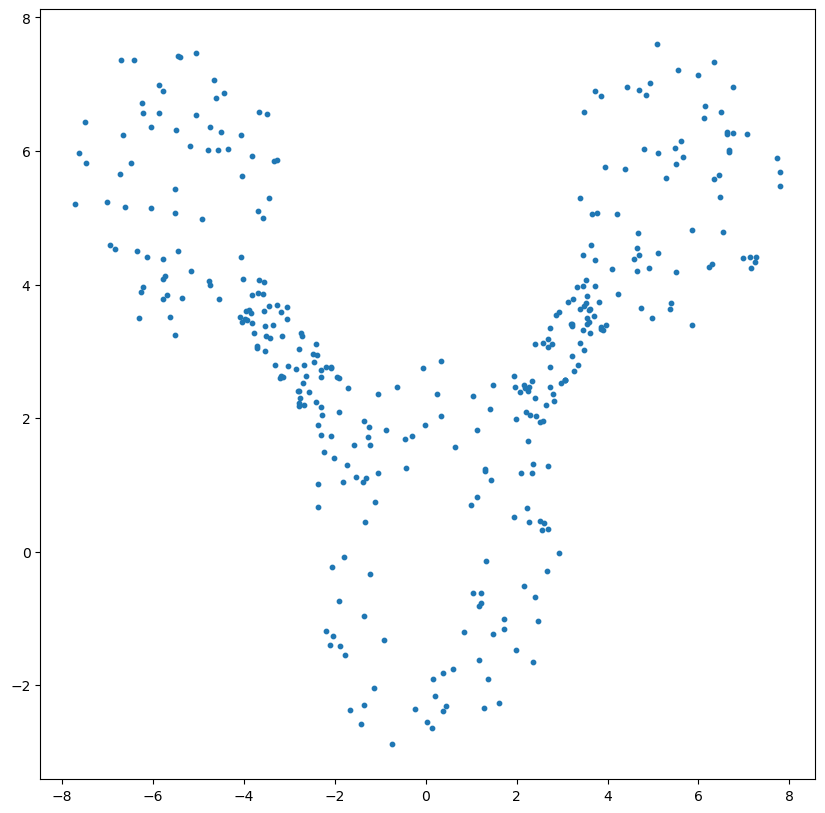

In [17]:
pts_per_thing = 100
phi = -np.pi/4
psi = -3*np.pi/4
pli = -np.pi/2
base_points = np.concatenate((np.array(annulus(pts_per_thing,0,1.2,3)),np.array(annulus(pts_per_thing/1.5,.0,0.0,2.3,(5.5,5.5))),np.array(annulus(pts_per_thing/1.5,.0,0.0,2.3,(5.5,-5.5))),(np.array(filled_rectangle(25,2.5,1))+np.array([3,-0.5])) @ np.array([[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]]),(np.array(filled_rectangle(25,2.5,1))+np.array([3,-0.5])) @ np.array([[np.cos(psi), -np.sin(psi)], [np.sin(psi), np.cos(psi)]])),axis = 0)
figtest = plt.figure('ttt', figsize=(10, 10))
axtest = plt.axes()
axtest.scatter(base_points[:, 0], base_points[:, 1],s=10)
axtest.xlim = (-1,4)
axtest.ylim = (-1,4)
plt.show() 

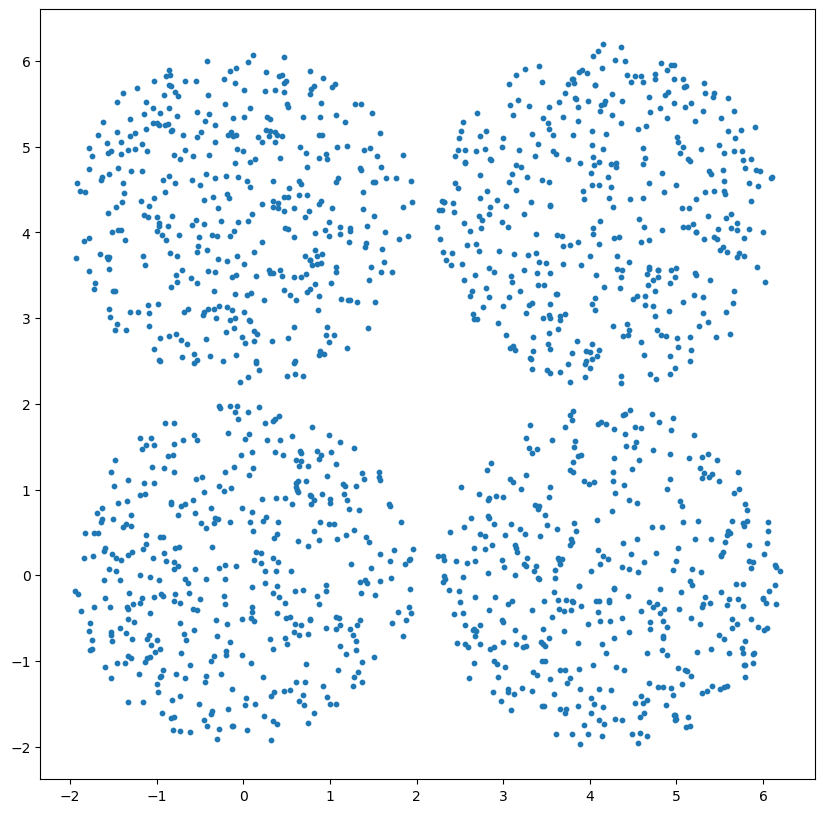

In [18]:
pts_per_thing = 400
base_points = np.concatenate((np.array(annulus(pts_per_thing,0,0.0,2)),np.array(annulus(pts_per_thing,.0,0.0,2,(0,4.2))),np.array(annulus(pts_per_thing,.0,0.0,2,(4.2,0))),np.array(annulus(pts_per_thing,.0,0.0,2,(4.2,4.2)))),axis = 0)
figtest = plt.figure('ttt', figsize=(10, 10))
axtest = plt.axes()
axtest.scatter(base_points[:, 0], base_points[:, 1],s=10)
axtest.xlim = (-1,4)
axtest.ylim = (-1,4)
plt.show() 